In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Procurement_kpi.csv")

In [2]:
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


In [3]:
df.shape

(777, 11)

In [4]:
df.columns

Index(['PO_ID', 'Supplier', 'Order_Date', 'Delivery_Date', 'Item_Category',
       'Order_Status', 'Quantity', 'Unit_Price', 'Negotiated_Price',
       'Defective_Units', 'Compliance'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             777 non-null    object 
 1   Supplier          777 non-null    object 
 2   Order_Date        777 non-null    object 
 3   Delivery_Date     690 non-null    object 
 4   Item_Category     777 non-null    object 
 5   Order_Status      777 non-null    object 
 6   Quantity          777 non-null    int64  
 7   Unit_Price        777 non-null    float64
 8   Negotiated_Price  777 non-null    float64
 9   Defective_Units   641 non-null    float64
 10  Compliance        777 non-null    object 
dtypes: float64(3), int64(1), object(7)
memory usage: 66.9+ KB


In [6]:
df.describe()

,Quantity,Unit_Price,Negotiated_Price,Defective_Units
count,777.000000,777.000000,777.000000,641.000000
mean,1094.660232,58.283822,53.660721,74.803432
std,647.844551,28.101315,26.094930,69.187870
min,51.000000,10.840000,9.270000,0.000000
25%,615.000000,33.290000,30.460000,26.000000
50%,1075.000000,58.950000,53.800000,49.000000
75%,1548.000000,83.130000,76.550000,100.000000
max,5000.000000,109.170000,107.390000,321.000000


In [9]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   PO_ID             777 non-null    object        
 1   Supplier          777 non-null    object        
 2   Order_Date        777 non-null    datetime64[ns]
 3   Delivery_Date     690 non-null    datetime64[ns]
 4   Item_Category     777 non-null    object        
 5   Order_Status      777 non-null    object        
 6   Quantity          777 non-null    int64         
 7   Unit_Price        777 non-null    float64       
 8   Negotiated_Price  777 non-null    float64       
 9   Defective_Units   641 non-null    float64       
 10  Compliance        777 non-null    object        
dtypes: datetime64[ns](2), float64(3), int64(1), object(5)
memory usage: 66.9+ KB


In [11]:
df.isnull().sum()

PO_ID                 0
Supplier              0
Order_Date            0
Delivery_Date        87
Item_Category         0
Order_Status          0
Quantity              0
Unit_Price            0
Negotiated_Price      0
Defective_Units     136
Compliance            0
dtype: int64

In [15]:
df[df['Delivery_Date'].isnull()]['Order_Status'].value_counts()

Order_Status
Delivered              68
Cancelled               8
Pending                 6
Partially Delivered     5
Name: count, dtype: int64

In [16]:
df['Delivery_Record_Missing'] = df['Delivery_Date'].isnull()

In [17]:
df['Delivery_Days'] = (
    df['Delivery_Date'] - df['Order_Date']
).dt.days

In [18]:
missing_delivery = df[df['Delivery_Date'].isnull()]

missing_delivery['Supplier'].value_counts()

Supplier
Alpha_Inc          24
Delta_Logistics    20
Epsilon_Group      17
Beta_Supplies      13
Gamma_Co           13
Name: count, dtype: int64

In [19]:
pd.crosstab(
    df['Order_Status'],
    df['Delivery_Record_Missing']
)

Delivery_Record_Missing,False,True
Order_Status,,
Cancelled,55,8
Delivered,492,68
Partially Delivered,68,5
Pending,75,6


In [20]:
df['Defective_Units'] = df['Defective_Units'].fillna(0)

In [21]:
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Delivery_Record_Missing,Delivery_Days
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,0.0,Yes,False,8.0
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,False,10.0
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,False,20.0
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,False,19.0
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,False,12.0


In [22]:
df.isnull().sum()

PO_ID                       0
Supplier                    0
Order_Date                  0
Delivery_Date              87
Item_Category               0
Order_Status                0
Quantity                    0
Unit_Price                  0
Negotiated_Price            0
Defective_Units             0
Compliance                  0
Delivery_Record_Missing     0
Delivery_Days              87
dtype: int64

In [ ]:
# Creating New Units

In [23]:
df['Savings_Per_Unit'] = (
    df['Unit_Price'] - df['Negotiated_Price']
)

In [24]:
df['Total_Savings'] = (
    df['Savings_Per_Unit'] * df['Quantity']
)

In [25]:
df['Defect_Rate'] = (
    df['Defective_Units'] / df['Quantity']
) * 100

In [26]:
df['Month'] = df['Order_Date'].dt.month_name()

In [27]:
df['Quarter'] = df['Order_Date'].dt.quarter

In [28]:
df.head()

,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance,Delivery_Record_Missing,Delivery_Days,Savings_Per_Unit,Total_Savings,Defect_Rate,Month,Quarter
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,0.0,Yes,False,8.0,2.32,2728.32,0.000000,October,4
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes,False,10.0,1.98,2987.82,15.573227,April,2
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes,False,20.0,3.25,2957.50,4.505495,January,1
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes,False,19.0,4.33,5819.52,8.333333,October,4
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No,False,12.0,3.54,4177.20,14.491525,September,3


Procurement Cost Analysis

In [33]:
df['original_cost'] = df['Unit_Price'] * df['Quantity']
df['negotiated_cost'] = df['Negotiated_Price'] * df['Quantity']
total_spend = df['negotiated_cost'].sum()
total_savings = df['Total_Savings'].sum()

print(total_savings)

3931126.4699999997


In [35]:
supplier_savings = df.groupby('Supplier')['Total_Savings'].sum().sort_values(ascending=False)
print(supplier_savings)

Supplier
Beta_Supplies      889940.89
Epsilon_Group      844980.18
Delta_Logistics    781976.49
Gamma_Co           725308.42
Alpha_Inc          688920.49
Name: Total_Savings, dtype: float64


Supplier Performance Analysis

In [39]:
supplier_spend = df.groupby('Supplier')['negotiated_cost'].sum().sort_values(ascending=False)
print(supplier_spend)

Supplier
Beta_Supplies      9858665.90
Epsilon_Group      9851156.06
Delta_Logistics    9236240.47
Gamma_Co           8587921.71
Alpha_Inc          7839712.25
Name: negotiated_cost, dtype: float64


In [44]:
supplier_price = df.groupby('Supplier')['Negotiated_Price'].mean().sort_values(ascending=False)
print(supplier_price)

Supplier
Gamma_Co           54.706713
Epsilon_Group      54.635482
Alpha_Inc          53.648156
Beta_Supplies      53.607885
Delta_Logistics    51.898304
Name: Negotiated_Price, dtype: float64


In [46]:
supplier_delivery = df.groupby('Supplier')['Delivery_Days'].mean().sort_values()
print(supplier_delivery)

Supplier
Gamma_Co           10.192308
Alpha_Inc          10.606838
Delta_Logistics    10.854305
Epsilon_Group      10.865772
Beta_Supplies      11.272727
Name: Delivery_Days, dtype: float64


In [47]:
supplier_quality = df.groupby('Supplier')['Defect_Rate'].mean().sort_values()
print(supplier_quality)

Supplier
Alpha_Inc           1.890548
Epsilon_Group       2.606269
Gamma_Co            4.497537
Beta_Supplies       8.272327
Delta_Logistics    10.866574
Name: Defect_Rate, dtype: float64


In [48]:
compliance = df.groupby('Supplier')['Compliance'].value_counts()
print(compliance)

Supplier         Compliance
Alpha_Inc        Yes           132
                 No              9
Beta_Supplies    Yes           118
                 No             38
Delta_Logistics  Yes           104
                 No             67
Epsilon_Group    Yes           163
                 No              3
Gamma_Co         Yes           123
                 No             20
Name: count, dtype: int64


Procurement Efficiency

In [49]:
df['Order_Status'].value_counts()

Order_Status
Delivered              560
Pending                 81
Partially Delivered     73
Cancelled               63
Name: count, dtype: int64

In [52]:
category_spend = df.groupby(
    'Item_Category'
)['negotiated_cost'].sum()

print(category_spend)

Item_Category
Electronics         8642550.60
MRO                10126608.86
Office Supplies    10007583.03
Packaging           8125712.48
Raw Materials       8471241.42
Name: negotiated_cost, dtype: float64


In [54]:
monthly_spend = df.groupby(
    'Month'
)['negotiated_cost'].sum()
print(monthly_spend)

Month
April        3638364.71
August       4339453.56
December     3441098.22
February     3151502.47
January      3982568.27
July         3659269.96
June         2952961.42
March        5337147.97
May          2693772.18
November     4118920.83
October      3651994.63
September    4406642.17
Name: negotiated_cost, dtype: float64


<Axes: xlabel='Month'>

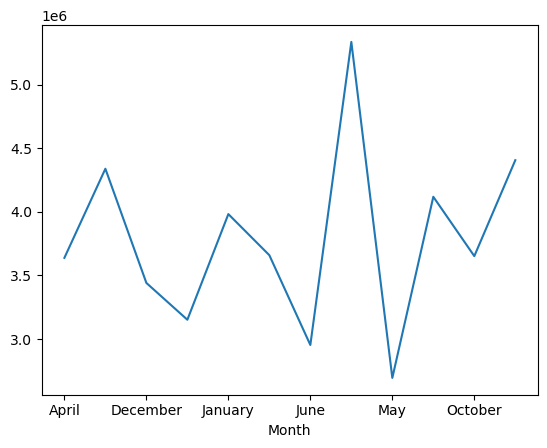

In [55]:
monthly_spend.plot(kind='line')

In [57]:
supplier_score = (
    supplier_delivery.rank()
    + supplier_quality.rank()
    + supplier_price.rank()
)
print(supplier_score.sort_values())

Supplier
Alpha_Inc           6.0
Delta_Logistics     9.0
Gamma_Co            9.0
Epsilon_Group      10.0
Beta_Supplies      11.0
dtype: float64
